# Installation and Importing Libraries

In [ ]:
# Toenable downloading from google drive
!pip -q install gdown

In [ ]:
# To use wavelet transform for compression
!pip -q install PyWavelets

In [ ]:
# Standard Python libraries
import os
import time
import random
from pathlib import Path
from google.colab import drive
import tarfile
import glob
import shutil
import tarfile

# Numerical and visualization libraries
import numpy as np
import matplotlib.pyplot as plt

# Image processing libraries
from PIL import Image
import json
import urllib.request

# Progress bar
from tqdm.auto import tqdm

# PyTorch deep learning libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset

# Wavelet transform library
import pywt

print("All libraries imported successfully.")

All libraries imported successfully.


#Download Mini-ImageNet Files
The Mini-ImageNet dataset files are stored in Google Drive as three `.tar` archive files: `train.tar`, `val.tar`, and `test.tar`. In this section, Google Drive is mounted, the dataset folder is checked, and the archive files are copied into the Colab runtime for faster processing.

The files are then extracted into a normal folder structure so that PyTorch can load the images later using `ImageFolder`.

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!gdown --folder "https://drive.google.com/drive/folders/17a09kkqVivZQFggCw9I_YboJ23tcexNM?usp=sharing" -O "/content/drive/MyDrive/EE413_MiniImageNet_Project data"

Retrieving folder contents
Processing file 1yKyKgxcnGMIAnA_6Vr2ilbpHMc9COg-v test.tar
Processing file 107FTosYIeBn5QbynR46YG91nHcJ70whs train.tar
Processing file 1hSMUMj5IRpf-nQs1OwgiQLmGZCN0KDWl val.tar
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1yKyKgxcnGMIAnA_6Vr2ilbpHMc9COg-v
From (redirected): https://drive.google.com/uc?id=1yKyKgxcnGMIAnA_6Vr2ilbpHMc9COg-v&confirm=t&uuid=c708030c-2cc3-4ca0-acea-06fbcc1b623b
To: /content/drive/MyDrive/EE413_MiniImageNet_Project data/test.tar
100% 39.2M/39.2M [00:00<00:00, 203MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=107FTosYIeBn5QbynR46YG91nHcJ70whs
From (redirected): https://drive.google.com/uc?id=107FTosYIeBn5QbynR46YG91nHcJ70whs&confirm=t&uuid=0c66648c-3383-46d0-87ba-374ced6c7039
To: /content/drive/MyDrive/EE413_MiniImageNet_Project data/train.tar
100% 126M/126M [00:00<00:00, 233MB/s]
Downloadin

In [ ]:
RAW_DIR = "/content/drive/MyDrive/EE413_MiniImageNet_Project data"

print(os.listdir(RAW_DIR))

['miniimagenet_classification', 'compressed_test', 'miniimagenet_classification_clean', 'test.tar', 'train.tar', 'val.tar']


In [ ]:
# Folder in Google Drive that contains train.tar, val.tar, and test.tar
DRIVE_DATA_DIR = Path("/content/drive/MyDrive/EE413_MiniImageNet_Project data")

# Local Colab folder where the .tar files will be copied
LOCAL_TAR_DIR = Path("/content/miniimagenet_tars")

# Folder where the dataset will be extracted
EXTRACT_DIR = Path("/content/miniimagenet_extracted")

# Required dataset files
required_tar_files = ["train.tar", "val.tar", "test.tar"]


def check_required_files(folder_path, required_files):
    """
    Check that all required dataset files exist.

    Parameters:
    folder_path: pathlib.Path
        Folder where the required files should exist.
    required_files: list
        List of required file names.

    Raises:
    FileNotFoundError:
        If the folder or any required file is missing.
    """
    if not folder_path.exists():
        raise FileNotFoundError(f"Dataset folder was not found: {folder_path}")

    missing_files = []

    for file_name in required_files:
        file_path = folder_path / file_name

        if not file_path.exists():
            missing_files.append(file_name)

    if missing_files:
        raise FileNotFoundError(f"Missing dataset files: {missing_files}")

    print("All required dataset files were found.")


check_required_files(DRIVE_DATA_DIR, required_tar_files)

print("Google Drive dataset folder:", DRIVE_DATA_DIR)
print("Local tar folder:", LOCAL_TAR_DIR)
print("Extraction folder:", EXTRACT_DIR)

All required dataset files were found.
Google Drive dataset folder: /content/drive/MyDrive/EE413_MiniImageNet_Project data
Local tar folder: /content/miniimagenet_tars
Extraction folder: /content/miniimagenet_extracted


In [ ]:
# Create local folder if it does not already exist
'''
The `.tar` files are copied from Google Drive to the Colab runtime.
This makes extraction faster nd avoids repeatedly reading large files
directly from Google Drive.
'''
LOCAL_TAR_DIR.mkdir(parents=True, exist_ok=True)

for file_name in required_tar_files:
    source_path = DRIVE_DATA_DIR / file_name
    destination_path = LOCAL_TAR_DIR / file_name

    if destination_path.exists():
        print(f"{file_name} already exists in Colab. Skipping copy.")
    else:
        print(f"Copying {file_name} to Colab...")
        shutil.copy2(source_path, destination_path)
        print(f"Finished copying {file_name}")

print("All dataset archive files are ready in Colab.")
print(os.listdir(LOCAL_TAR_DIR))

Copying train.tar to Colab...
Finished copying train.tar
Copying val.tar to Colab...
Finished copying val.tar
Copying test.tar to Colab...
Finished copying test.tar
All dataset archive files are ready in Colab.
['test.tar', 'train.tar', 'val.tar']


In [ ]:
# Extract Mini-ImageNet Archive Files
''' The dataset files are stored as `.tar` archive files. Each archive contains image folders.
The code below extracts `train.tar`, `val.tar`, and `test.tar` into the Colab runtime
'''

# Create extraction folder
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

for file_name in required_tar_files:
    tar_path = LOCAL_TAR_DIR / file_name

    print(f"Extracting {file_name}...")

    try:
        with tarfile.open(tar_path, "r") as tar:
            tar.extractall(EXTRACT_DIR)

        print(f"Finished extracting {file_name}")

    except tarfile.TarError as error:
        print(f"Error extracting {file_name}: {error}")

print("Extraction completed.")
print("Extracted folders:", os.listdir(EXTRACT_DIR))


Extracting train.tar...


/tmp/ipykernel_584/1406600462.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(EXTRACT_DIR)


Finished extracting train.tar
Extracting val.tar...
Finished extracting val.tar
Extracting test.tar...
Finished extracting test.tar
Extraction completed.
Extracted folders: ['val', 'train', 'test']


In [ ]:
# Extraction verification
'''
the dataset structure is checked by counting the number
of classes and images in each split
'''
for split in ["train", "val", "test"]:
    split_dir = EXTRACT_DIR / split

    if not split_dir.exists():
        print(f"{split} folder was not found.")
        continue

    class_folders = [p for p in split_dir.iterdir() if p.is_dir()]
    image_count = sum(len(list(class_folder.glob("*"))) for class_folder in class_folders)

    print(split)
    print("Number of classes:", len(class_folders))
    print("Number of images:", image_count)
    print("Example classes:", [p.name for p in class_folders[:5]])
    print("-" * 40)

train
Number of classes: 64
Number of images: 38400
Example classes: ['n04509417', 'n04596742', 'n02091831', 'n03998194', 'n02074367']
----------------------------------------
val
Number of classes: 16
Number of images: 9600
Example classes: ['n02091244', 'n03770439', 'n03075370', 'n02138441', 'n02981792']
----------------------------------------
test
Number of classes: 20
Number of images: 12000
Example classes: ['n04418357', 'n02099601', 'n03775546', 'n02129165', 'n04146614']
----------------------------------------


#Data Preparation

The downloaded Mini-ImageNet dataset is organized using the original few-shot split: 64 training classes, 16 validation classes, and 20 testing classes. However, for this classification project, the dataset is reorganized so that all 100 classes appear in both the training and testing sets.

For each class, 500 images are assigned to the training set and 100 images are assigned to the testing set.

In [ ]:
# Final dataset folder after reorganizing Mini-ImageNet
CLASSIFICATION_DIR = Path("/content/miniimagenet_classification")

# New train and test folders
FINAL_TRAIN_DIR = CLASSIFICATION_DIR / "train"
FINAL_TEST_DIR = CLASSIFICATION_DIR / "test"

print("Classification dataset folder:", CLASSIFICATION_DIR)
print("Final training folder:", FINAL_TRAIN_DIR)
print("Final testing folder:", FINAL_TEST_DIR)

Classification dataset folder: /content/miniimagenet_classification
Final training folder: /content/miniimagenet_classification/train
Final testing folder: /content/miniimagenet_classification/test


In [ ]:
def collect_images_by_class(extract_dir):
    """
    Collect image paths from the original Mini-ImageNet train, val, and test folders.

    Parameters:
    extract_dir: pathlib.Path
        Path to the extracted Mini-ImageNet folder.

    Returns:
    images_by_class: dict
        Dictionary where each key is a class ID and each value is a list of image paths.
    """
    image_extensions = {".jpg", ".jpeg", ".png"}
    images_by_class = {}

    for split in ["train", "val", "test"]:
        split_dir = extract_dir / split

        if not split_dir.exists():
            raise FileNotFoundError(f"Original split folder not found: {split_dir}")

        for class_dir in split_dir.iterdir():
            if class_dir.is_dir():
                class_name = class_dir.name

                image_paths = [
                    image_path for image_path in class_dir.iterdir()
                    if image_path.suffix.lower() in image_extensions
                ]

                if len(image_paths) == 0:
                    raise ValueError(f"No images found in class folder: {class_dir}")

                images_by_class[class_name] = image_paths

    return images_by_class


images_by_class = collect_images_by_class(EXTRACT_DIR)

print("Total classes collected:", len(images_by_class))

Total classes collected: 100


In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
random.seed(42)
EXTRACT_DIR = Path("/content/miniimagenet_extracted")
OUTPUT_DIR = Path("/content/miniimagenet_classification")

# Delete old output folder if it exists
if OUTPUT_DIR.exists():
    shutil.rmtree(OUTPUT_DIR)

image_exts = {".jpg", ".jpeg", ".png"}

# Step 1: collect all images from train, val, and test
images_by_class = {}

for split in ["train", "val", "test"]:
    split_dir = EXTRACT_DIR / split

    for class_dir in split_dir.iterdir():
        if class_dir.is_dir():
            class_name = class_dir.name

            images = [
                p for p in class_dir.iterdir()
                if p.suffix.lower() in image_exts
            ]

            images_by_class[class_name] = images

print("Total classes found:", len(images_by_class))

# Step 2: create new 500 train / 100 test split for each class
for class_name, images in images_by_class.items():
    random.shuffle(images)

    train_images = images[:500]
    test_images = images[500:600]

    train_class_dir = OUTPUT_DIR / "train" / class_name
    test_class_dir = OUTPUT_DIR / "test" / class_name

    train_class_dir.mkdir(parents=True, exist_ok=True)
    test_class_dir.mkdir(parents=True, exist_ok=True)

    for i, img_path in enumerate(train_images):
        shutil.copy2(img_path, train_class_dir / f"{i:04d}_{img_path.name}")

    for i, img_path in enumerate(test_images):
        shutil.copy2(img_path, test_class_dir / f"{i:04d}_{img_path.name}")

print("Done creating classification dataset.")

Total classes found: 100
Done creating classification dataset.


In [ ]:
# this part was created with the help of chatgpt to display progress bar
def create_classification_split(
    images_by_class,
    output_dir,
    train_images_per_class=500,
    test_images_per_class=100,
    seed=42
):
    """
    Create a classification dataset with 500 training images and 100 testing images per class.

    Parameters:
    images_by_class: dict
        Dictionary where each key is a class ID and each value is a list of image paths.
    output_dir: pathlib.Path
        Output folder for the reorganized dataset.
    train_images_per_class: int
        Number of training images per class.
    test_images_per_class: int
        Number of testing images per class.
    seed: int
        Random seed for reproducible shuffling.

    Returns:
    output_dir: pathlib.Path
        Path to the created classification dataset.
    """
    if output_dir.exists():
        print("Existing classification dataset found. Removing old folder...")
        shutil.rmtree(output_dir)

    random.seed(seed)

    for class_name, image_paths in tqdm(images_by_class.items(), desc="Creating classification split"):
        image_paths = list(image_paths)
        random.shuffle(image_paths)

        required_images = train_images_per_class + test_images_per_class

        if len(image_paths) < required_images:
            raise ValueError(
                f"Class {class_name} has only {len(image_paths)} images, "
                f"but {required_images} are required."
            )

        train_images = image_paths[:train_images_per_class]
        test_images = image_paths[train_images_per_class:required_images]

        train_class_dir = output_dir / "train" / class_name
        test_class_dir = output_dir / "test" / class_name

        train_class_dir.mkdir(parents=True, exist_ok=True)
        test_class_dir.mkdir(parents=True, exist_ok=True)

        for index, image_path in enumerate(train_images):
            output_path = train_class_dir / f"{index:04d}_{image_path.name}"
            shutil.copy2(image_path, output_path)

        for index, image_path in enumerate(test_images):
            output_path = test_class_dir / f"{index:04d}_{image_path.name}"
            shutil.copy2(image_path, output_path)

    print("Classification split created successfully.")
    return output_dir


create_classification_split(
    images_by_class=images_by_class,
    output_dir=CLASSIFICATION_DIR,
    train_images_per_class=500,
    test_images_per_class=100,
    seed=SEED
)

Existing classification dataset found. Removing old folder...


Creating classification split:   0%|          | 0/100 [00:00<?, ?it/s]

Classification split created successfully.


PosixPath('/content/miniimagenet_classification')

In [ ]:
def verify_final_split(classification_dir, expected_classes=100):
    """
    Verify the final train/test classification split.
    """
    for split in ["train", "test"]:
        split_dir = classification_dir / split

        if not split_dir.exists():
            raise FileNotFoundError(f"{split} folder was not found: {split_dir}")

        class_folders = [p for p in split_dir.iterdir() if p.is_dir()]
        image_count = sum(len(list(class_folder.glob("*"))) for class_folder in class_folders)

        print(split)
        print("Number of classes:", len(class_folders))
        print("Number of images:", image_count)
        print("-" * 40)

        if len(class_folders) != expected_classes:
            raise ValueError(
                f"Expected {expected_classes} classes in {split}, "
                f"but found {len(class_folders)}."
            )


verify_final_split(CLASSIFICATION_DIR)

train
Number of classes: 100
Number of images: 50000
----------------------------------------
test
Number of classes: 100
Number of images: 10000
----------------------------------------


ImageNet class labels loaded successfully.


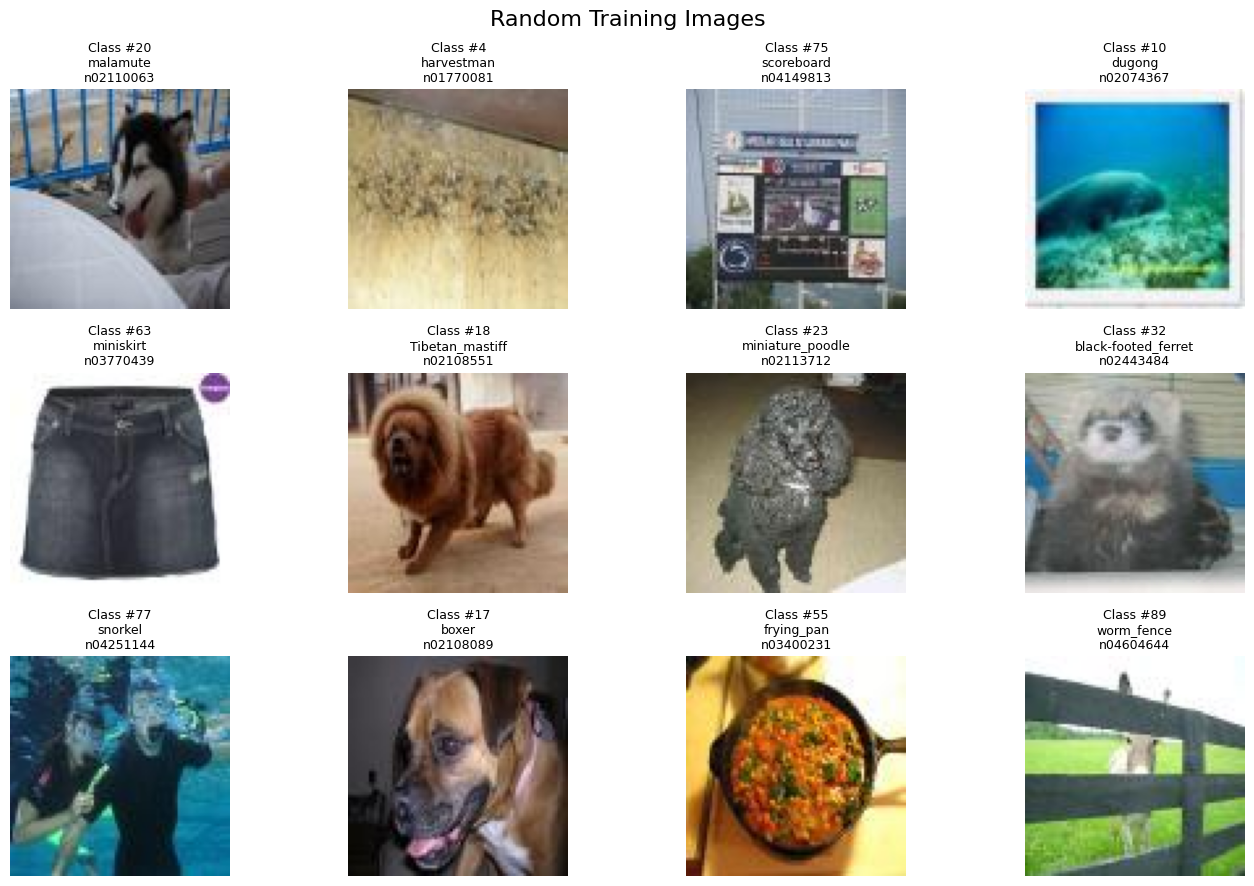

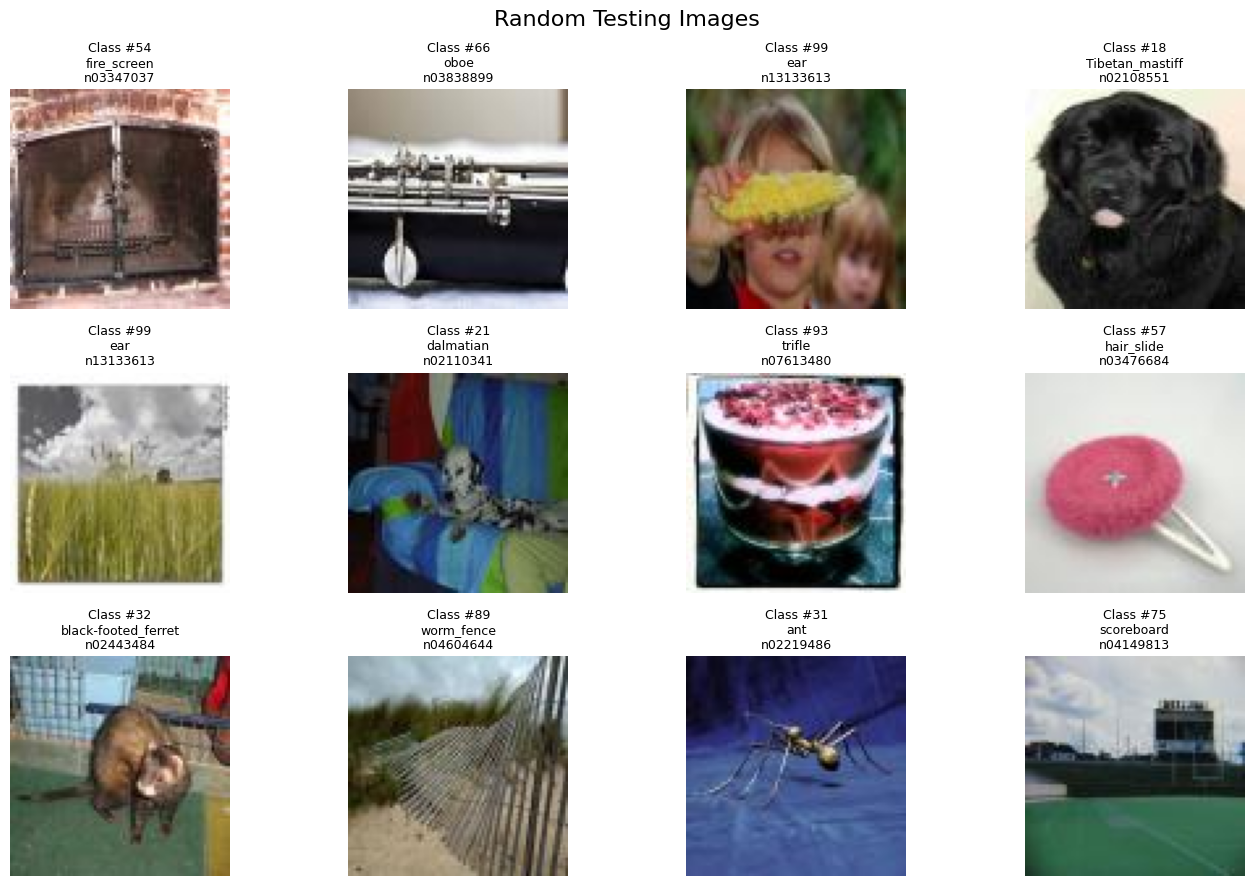

In [ ]:
# Load dataset structure to get class IDs and PyTorch class numbers
exploration_dataset = datasets.ImageFolder(root=FINAL_TRAIN_DIR)

class_ids = exploration_dataset.classes
class_to_idx = exploration_dataset.class_to_idx

# Load ImageNet class ID to readable label mapping
class_mapping_url = "https://storage.googleapis.com/download.tensorflow.org/data/imagenet_class_index.json"
mapping_file = "imagenet_class_index.json"

try:
    urllib.request.urlretrieve(class_mapping_url, mapping_file)

    with open(mapping_file, "r") as file:
        imagenet_class_index = json.load(file)

    id_to_name = {
        value[0]: value[1]
        for value in imagenet_class_index.values()
    }

    print("ImageNet class labels loaded successfully.")

except Exception as error:
    print("Could not load ImageNet labels.")
    print("Error:", error)
    id_to_name = {}


def show_random_images_with_labels(folder_path, title, num_images=12):
    """
    Display random images with class number, class ID, and readable class label.
    """
    class_folders = [folder for folder in folder_path.iterdir() if folder.is_dir()]

    plt.figure(figsize=(14, 9))
    plt.suptitle(title, fontsize=16)

    for i in range(num_images):
        class_dir = random.choice(class_folders)
        image_path = random.choice(list(class_dir.glob("*")))

        image = Image.open(image_path).convert("RGB")

        class_id = class_dir.name
        class_number = class_to_idx[class_id]
        class_label = id_to_name.get(class_id, "Unknown class")

        plt.subplot(3, 4, i + 1)
        plt.imshow(image)
        plt.title(
            f"Class #{class_number}\n{class_label}\n{class_id}",
            fontsize=9
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Show random samples from training and testing sets
show_random_images_with_labels(
    folder_path=FINAL_TRAIN_DIR,
    title="Random Training Images",
    num_images=12
)

show_random_images_with_labels(
    folder_path=FINAL_TEST_DIR,
    title="Random Testing Images",
    num_images=12
)

# ResNet-18 Fine-Tuning and Evaluation on Compressed Data

This section focuses on my part of the project, which is using a pretrained ResNet-18 model for Mini-ImageNet classification. The main objective is to fine-tune ResNet-18 on the original uncompressed Mini-ImageNet training data, establish a baseline accuracy on the original test set, and then evaluate how the model performance changes when the test images are compressed using wavelet-based compression.

### Model Architecture

ResNet-18 was selected as the pretrained deep learning model because it is relatively small, fast to train, and suitable for transfer learning. The model was originally pretrained on ImageNet with 1000 output classes. Since Mini-ImageNet contains 100 classes, the final fully connected layer of ResNet-18 was replaced with a new linear layer that outputs 100 class scores.

The pretrained layers were kept because they already learned useful visual features such as edges, textures, shapes, and object patterns. Fine-tuning allows the model to adapt these general ImageNet features to the Mini-ImageNet classification task.

### Hyperparameters

The ResNet-18 model was fine-tuned using the following setup:

- Model: ResNet-18
- Pretrained weights: ImageNet pretrained weights
- Number of classes: 100
- Input image size: 96 × 96 pixels
- Batch size: 64
- Loss function: CrossEntropyLoss
- Optimizer: Adam
- Learning rate: 0.0001
- Weight decay: 0.0001
- Validation split: 10% of the training data
- Training device: GPU when available

### Training Process

The prepared Mini-ImageNet dataset contains 100 classes, with 500 training images and 100 testing images per class. Before training, 10% of the training set was separated and used as a validation set. This gave 45,000 training images, 5,000 validation images, and 10,000 testing images.

During training, each batch of images was passed through the ResNet-18 model. The model predictions were compared with the true labels using CrossEntropyLoss. Then, the Adam optimizer updated the model weights to reduce the classification error. After each epoch, the model was evaluated on the validation set to monitor its performance on unseen data.

The best model checkpoint was saved based on the highest validation accuracy instead of using the final epoch directly. This is important because the model started to show signs of overfitting: the training accuracy continued to increase, while the validation accuracy stopped improving.

### Baseline Result on Original Images

After fine-tuning, the best ResNet-18 model was evaluated on the original uncompressed Mini-ImageNet test set. The model achieved a test accuracy of 72.37%. This result is used as the baseline accuracy before evaluating the effect of wavelet compression.

### Evaluation on Wavelet-Compressed Images

After establishing the baseline, the same trained ResNet-18 model was tested on wavelet-compressed versions of the test set. Three compression ratios were used:

- 2:1 compression
- 5:1 compression
- 10:1 compression

For each compression ratio, a separate compressed test folder was created. The trained ResNet-18 model was then evaluated on each compressed test set using the same preprocessing steps as the original test set.

The purpose of this step is to measure how classification accuracy changes as compression becomes stronger. The accuracy drop is calculated by comparing the compressed test accuracy with the original baseline accuracy of 72.37%.

### Summary

This part establishes the ResNet-18 baseline and evaluates its robustness against wavelet compression. The original test accuracy is used as the reference point, and the compressed test results show how much model performance degrades when image details are removed by wavelet coefficient thresholding.

In [ ]:
# Use GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [ ]:
# ResNet-18 Setup, Loss Function, and Optimizer

# Use GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Number of Mini-ImageNet classes
num_classes = 100

# Training settings
learning_rate = 0.0001
weight_decay = 0.0001
num_epochs = 5

# File name for saving the best model
best_model_path = "best_resnet18_miniimagenet.pth"

# Load pretrained ResNet-18
# The model was originally trained on ImageNet with 1000 classes
weights = models.ResNet18_Weights.DEFAULT
resnet18 = models.resnet18(weights=weights)

# Replace the final layer to match Mini-ImageNet 100 classes
in_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(in_features, num_classes)

# Move model to GPU/CPU
resnet18 = resnet18.to(device)

# Loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer updates the model weights during training
optimizer = optim.Adam(
    resnet18.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay
)

print("ResNet-18 setup completed.")
print("Using device:", device)
print("Final layer:", resnet18.fc)
print("Loss function:", criterion)
print("Optimizer: Adam")
print("Learning rate:", learning_rate)
print("Weight decay:", weight_decay)
print("Number of epochs:", num_epochs)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 278MB/s]


ResNet-18 setup completed.
Using device: cuda
Final layer: Linear(in_features=512, out_features=100, bias=True)
Loss function: CrossEntropyLoss()
Optimizer: Adam
Learning rate: 0.0001
Weight decay: 0.0001
Number of epochs: 5


In [ ]:
# Create DataLoaders for ResNet-18

# Training and testing folders from the prepared classification dataset
train_dir = CLASSIFICATION_DIR / "train"
test_dir = CLASSIFICATION_DIR / "test"

# ImageNet normalization because ResNet-18 is pretrained on ImageNet
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

# Transform for training images
train_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Transform for validation and test images
eval_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# Load training folder twice:
# one version with augmentation for training
# one version without augmentation for validation
full_train_dataset_aug = datasets.ImageFolder(root=train_dir, transform=train_transform)
full_train_dataset_eval = datasets.ImageFolder(root=train_dir, transform=eval_transform)

# Load test dataset
test_dataset = datasets.ImageFolder(root=test_dir, transform=eval_transform)

# Create train/validation split
num_train = len(full_train_dataset_aug)
indices = np.arange(num_train)

np.random.seed(42)
np.random.shuffle(indices)

val_ratio = 0.10
val_size = int(num_train * val_ratio)

val_indices = indices[:val_size]
train_indices = indices[val_size:]

train_dataset = Subset(full_train_dataset_aug, train_indices)
val_dataset = Subset(full_train_dataset_eval, val_indices)

# Create DataLoaders
batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print("DataLoaders are ready.")
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Testing images:", len(test_dataset))
print("Number of classes:", len(full_train_dataset_aug.classes))

DataLoaders are ready.
Training images: 45000
Validation images: 5000
Testing images: 10000
Number of classes: 100


In [ ]:
# Train and Validate ResNet-18
'''
this cell trains ResNet-18 and saves the best version
as best_resnet18_miniimagenet.pth
'''

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()  # training mode

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()        # clear old gradients
        outputs = model(images)      # model prediction
        loss = criterion(outputs, labels)  # calculate error

        loss.backward()              # calculate gradients
        optimizer.step()             # update weights

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)  # choose class with highest score
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


def evaluate(model, data_loader, criterion, device):
    model.eval()  # evaluation mode

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():  # no weight update during validation/testing
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


# Save training history for plots later
history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_accuracy = 0.0

for epoch in range(num_epochs):
    start_time = time.time()

    train_loss, train_accuracy = train_one_epoch(
        resnet18,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = evaluate(
        resnet18,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    # Save the best model based on validation accuracy
    if val_accuracy > best_val_accuracy:
        best_val_accuracy = val_accuracy
        torch.save(resnet18.state_dict(), best_model_path)

    epoch_time = time.time() - start_time

    print(f"Epoch [{epoch + 1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Accuracy: {train_accuracy * 100:.2f}%")
    print(f"Val Loss:   {val_loss:.4f} | Val Accuracy:   {val_accuracy * 100:.2f}%")
    print(f"Time: {epoch_time:.2f} seconds")
    print("-" * 60)

print("Training finished.")
print(f"Best validation accuracy: {best_val_accuracy * 100:.2f}%")

Epoch [1/5]
Train Loss: 1.7974 | Train Accuracy: 57.17%
Val Loss:   1.1829 | Val Accuracy:   68.04%
Time: 8.15 seconds
------------------------------------------------------------
Epoch [2/5]
Train Loss: 0.8923 | Train Accuracy: 76.04%
Val Loss:   1.1116 | Val Accuracy:   69.60%
Time: 6.63 seconds
------------------------------------------------------------
Epoch [3/5]
Train Loss: 0.5850 | Train Accuracy: 84.26%
Val Loss:   1.0924 | Val Accuracy:   71.08%
Time: 6.56 seconds
------------------------------------------------------------
Epoch [4/5]
Train Loss: 0.3852 | Train Accuracy: 89.72%
Val Loss:   1.1255 | Val Accuracy:   71.08%
Time: 6.72 seconds
------------------------------------------------------------
Epoch [5/5]
Train Loss: 0.2566 | Train Accuracy: 93.32%
Val Loss:   1.1635 | Val Accuracy:   71.00%
Time: 6.54 seconds
------------------------------------------------------------
Training finished.
Best validation accuracy: 71.08%


In [ ]:
# Load the best saved weights
resnet18.load_state_dict(
    torch.load(best_model_path, map_location=device)
)

# Make sure the model is on GPU/CPU correctly
resnet18 = resnet18.to(device)

# Evaluate on the test set
test_loss, test_accuracy = evaluate(
    resnet18,
    test_loader,
    criterion,
    device
)
'''
The fine-tuned ResNet-18 model achieved a test accuracy of 72.37%
on the original uncompressed Mini-ImageNet test set.
This result is used as the baseline performance
before applying wavelet-based compression
and compressed sensing experiments.
'''

# number of trainable parameters & their weight
total_params = sum(p.numel() for p in resnet18.parameters())
trainable_params = sum(p.numel() for p in resnet18.parameters() if p.requires_grad)

print("Model: ResNet-18")
print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)
print("Final layer:", resnet18.fc)
print(f"ResNet-18 Test Loss: {test_loss:.4f}")
print(f"ResNet-18 Test Accuracy: {test_accuracy*100:.2f}%")

Model: ResNet-18
Total parameters: 11227812
Trainable parameters: 11227812
Final layer: Linear(in_features=512, out_features=100, bias=True)
ResNet-18 Test Loss: 1.0365
ResNet-18 Test Accuracy: 72.04%


In [ ]:
# Wavelet Compression Function
def wavelet_compress_image(pil_img, wavelet="haar", level=2, ratio=5):
    """
    Compress an RGB image using wavelet transform and hard thresholding.

    Parameters:
    pil_img: PIL image
        Input image.
    wavelet: str
        Type of wavelet used, for example 'haar' or 'db2'.
    level: int
        Number of wavelet decomposition levels.
    ratio: int or float
        Compression ratio.
        ratio = 2 means keep 1/2 of the coefficients.
        ratio = 5 means keep 1/5 of the coefficients.
        ratio = 10 means keep 1/10 of the coefficients.

    Returns:
    compressed_img: PIL image
        Reconstructed compressed image.
    """

    # Convert image to RGB and scale pixel values from 0-255 to 0-1
    img = np.array(pil_img.convert("RGB")).astype(np.float32) / 255.0

    compressed_channels = []

    # Apply wavelet compression separately to R, G, and B channels
    for channel in range(3):
        channel_data = img[:, :, channel]

        # Apply 2D wavelet decomposition
        coeffs = pywt.wavedec2(channel_data, wavelet=wavelet, level=level)

        # Convert wavelet coefficients into one array
        coeff_array, coeff_slices = pywt.coeffs_to_array(coeffs)

        # Flatten coefficients to make thresholding easier
        flat_coeffs = coeff_array.ravel()

        # Number of coefficients to keep
        total_coeffs = flat_coeffs.size
        keep_count = int(total_coeffs / ratio)
        keep_count = max(1, keep_count)

        # Find indices of the largest coefficients by magnitude
        largest_indices = np.argpartition(np.abs(flat_coeffs), -keep_count)[-keep_count:]

        # Hard thresholding: keep only largest coefficients and set others to zero
        thresholded_flat = np.zeros_like(flat_coeffs)
        thresholded_flat[largest_indices] = flat_coeffs[largest_indices]

        # Reshape back to wavelet coefficient array
        thresholded_array = thresholded_flat.reshape(coeff_array.shape)

        # Convert array back to wavelet coefficient structure
        thresholded_coeffs = pywt.array_to_coeffs(
            thresholded_array,
            coeff_slices,
            output_format="wavedec2"
        )

        # Reconstruct the image channel using inverse wavelet transform
        reconstructed_channel = pywt.waverec2(thresholded_coeffs, wavelet=wavelet)

        # Crop in case reconstruction gives slightly different size
        reconstructed_channel = reconstructed_channel[:img.shape[0], :img.shape[1]]

        compressed_channels.append(reconstructed_channel)

    # Combine R, G, and B channels again
    compressed_img = np.stack(compressed_channels, axis=2)

    # Keep pixel values between 0 and 1
    compressed_img = np.clip(compressed_img, 0, 1)

    # Convert back to PIL image with pixel values 0-255
    compressed_img = Image.fromarray((compressed_img * 255).astype(np.uint8))

    return compressed_img

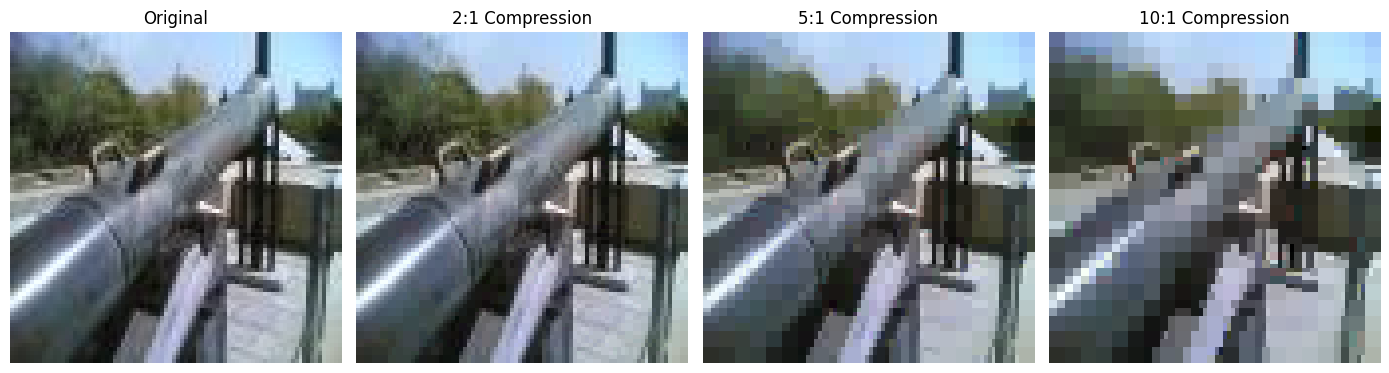

Class ID: n02950826
Image path: /content/miniimagenet_classification/test/n02950826/0025_n0295082600000683.jpg


In [ ]:
# Visualize Original vs Wavelet-Compressed Images

TEST_DIR = Path("/content/miniimagenet_classification/test")

# Get all class folders
class_folders = [p for p in TEST_DIR.iterdir() if p.is_dir()]

# Pick one random class and one random image
class_dir = random.choice(class_folders)
image_path = random.choice(list(class_dir.glob("*")))

original_img = Image.open(image_path).convert("RGB")

# Apply wavelet compression at different ratios
compressed_2 = wavelet_compress_image(original_img, ratio=2)
compressed_5 = wavelet_compress_image(original_img, ratio=5)
compressed_10 = wavelet_compress_image(original_img, ratio=10)

# Display original and compressed images
plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(original_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(compressed_2)
plt.title("2:1 Compression")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(compressed_5)
plt.title("5:1 Compression")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(compressed_10)
plt.title("10:1 Compression")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Class ID:", class_dir.name)
print("Image path:", image_path)

In [ ]:

# Create Wavelet-Compressed Test Sets

ORIGINAL_TEST_DIR = Path("/content/miniimagenet_classification/test")

# Where compressed test sets will be saved
COMPRESSED_ROOT = Path("/content/miniimagenet_wavelet_compressed")

# Compression ratios required in the project
compression_ratios = [2, 5, 10]


def create_compressed_test_set(original_test_dir, output_root, ratio):
    """
    Create a compressed copy of the test set using wavelet compression.

    Parameters:
    original_test_dir: Path
        Path to the original test folder.
    output_root: Path
        Main folder where compressed datasets will be saved.
    ratio: int
        Compression ratio, such as 2, 5, or 10.
    """

    output_dir = output_root / f"ratio_{ratio}"
    output_dir.mkdir(parents=True, exist_ok=True)

    class_folders = sorted([p for p in original_test_dir.iterdir() if p.is_dir()])

    for class_dir in tqdm(class_folders, desc=f"Creating {ratio}:1 compressed test set"):
        class_output_dir = output_dir / class_dir.name
        class_output_dir.mkdir(parents=True, exist_ok=True)

        image_paths = sorted(list(class_dir.glob("*")))

        for image_path in image_paths:
            output_path = class_output_dir / image_path.name

            # Skip image if it was already compressed before
            if output_path.exists():
                continue

            original_img = Image.open(image_path).convert("RGB")
            compressed_img = wavelet_compress_image(original_img, ratio=ratio)
            compressed_img.save(output_path)

    print(f"Finished creating {ratio}:1 compressed test set.")
    print("Saved at:", output_dir)
# Generate Compressed Test Sets

for ratio in compression_ratios:
    create_compressed_test_set(
        original_test_dir=ORIGINAL_TEST_DIR,
        output_root=COMPRESSED_ROOT,
        ratio=ratio
    )

Creating 2:1 compressed test set:   0%|          | 0/100 [00:00<?, ?it/s]

Finished creating 2:1 compressed test set.
Saved at: /content/miniimagenet_wavelet_compressed/ratio_2


Creating 5:1 compressed test set:   0%|          | 0/100 [00:00<?, ?it/s]

Finished creating 5:1 compressed test set.
Saved at: /content/miniimagenet_wavelet_compressed/ratio_5


Creating 10:1 compressed test set:   0%|          | 0/100 [00:00<?, ?it/s]

Finished creating 10:1 compressed test set.
Saved at: /content/miniimagenet_wavelet_compressed/ratio_10


In [ ]:
# Same transform used during original test evaluation
compressed_test_transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

compressed_loaders = {}

for ratio in compression_ratios:
    compressed_dir = COMPRESSED_ROOT / f"ratio_{ratio}"

    compressed_dataset = datasets.ImageFolder(
        root=compressed_dir,
        transform=compressed_test_transform
    )

    compressed_loader = DataLoader(
        compressed_dataset,
        batch_size=64,
        shuffle=False,
        num_workers=2
    )

    compressed_loaders[ratio] = compressed_loader

    print(f"{ratio}:1 compressed dataset")
    print("Images:", len(compressed_dataset))
    print("Classes:", len(compressed_dataset.classes))
    print("-" * 40)

2:1 compressed dataset
Images: 10000
Classes: 100
----------------------------------------
5:1 compressed dataset
Images: 10000
Classes: 100
----------------------------------------
10:1 compressed dataset
Images: 10000
Classes: 100
----------------------------------------


In [ ]:
# Evaluation on 2:1 Compressed test
compressed_dir_2 = COMPRESSED_ROOT / "ratio_2"

compressed_dataset_2 = datasets.ImageFolder(
    root=compressed_dir_2,
    transform=compressed_test_transform
)

compressed_loader_2 = DataLoader(
    compressed_dataset_2,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

loss_2, accuracy_2 = evaluate(
    resnet18,
    compressed_loader_2,
    criterion,
    device
)

print("2:1 Wavelet Compression")
print(f"Test Loss: {loss_2:.4f}")
print(f"Test Accuracy: {accuracy_2*100:.2f}%")
print(f"Accuracy Drop from Original Baseline: {72.37 - accuracy_2*100:.2f}%")

2:1 Wavelet Compression
Test Loss: 1.0395
Test Accuracy: 72.28%
Accuracy Drop from Original Baseline: 0.09%


In [ ]:
# Evaluation on 5:1 compressed test set

compressed_dir_5 = COMPRESSED_ROOT / "ratio_5"

compressed_dataset_5 = datasets.ImageFolder(
    root=compressed_dir_5,
    transform=compressed_test_transform
)

compressed_loader_5 = DataLoader(
    compressed_dataset_5,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

loss_5, accuracy_5 = evaluate(
    resnet18,
    compressed_loader_5,
    criterion,
    device
)

print("5:1 Wavelet Compression")
print(f"Test Loss: {loss_5:.4f}")
print(f"Test Accuracy: {accuracy_5*100:.2f}%")
print(f"Accuracy Drop from Original Baseline: {72.37 - accuracy_5*100:.2f}%")

5:1 Wavelet Compression
Test Loss: 1.1813
Test Accuracy: 68.80%
Accuracy Drop from Original Baseline: 3.57%


In [ ]:
# 10:1 Wavelet-compressed test set

compressed_dir_10 = COMPRESSED_ROOT / "ratio_10"

compressed_dataset_10 = datasets.ImageFolder(
    root=compressed_dir_10,
    transform=compressed_test_transform
)

compressed_loader_10 = DataLoader(
    compressed_dataset_10,
    batch_size=64,
    shuffle=False,
    num_workers=2
)

loss_10, accuracy_10 = evaluate(
    resnet18,
    compressed_loader_10,
    criterion,
    device
)

print("10:1 Wavelet Compression")
print(f"Test Loss: {loss_10:.4f}")
print(f"Test Accuracy: {accuracy_10*100:.2f}%")
print(f"Accuracy Drop from Original Baseline: {72.37 - accuracy_10*100:.2f}%")

10:1 Wavelet Compression
Test Loss: 2.0792
Test Accuracy: 50.34%
Accuracy Drop from Original Baseline: 22.03%


# MobileNetV2 Training, Validation, and Baseline Evaluation

This code prepares the Mini-ImageNet training, validation, and test data for fine-tuning a pretrained MobileNetV2 model. The GPU is selected automatically when available to speed up training. The training and testing folders created earlier are used as the input dataset paths.

The images are preprocessed using different transformations for training and evaluation. For the training set, each image is resized to 96 × 96 pixels, randomly flipped horizontally for data augmentation, converted to a tensor, and normalized using ImageNet mean and standard deviation values. The validation and test sets use the same resizing and normalization steps, but without random flipping so that evaluation remains consistent.

The training set is split into training and validation subsets using an 80/20 ratio. A fixed random seed is used to make the split reproducible. The `ImageFolder` class loads the dataset from the folder structure, and `Subset` is used so that the training and validation subsets can use different preprocessing steps while still coming from the same original data.

A pretrained MobileNetV2 model is loaded from the PyTorch model zoo. Since the original model was trained on ImageNet with 1000 classes, the final classification layer is replaced with a new fully connected layer that outputs 100 classes, matching the Mini-ImageNet task. The model is then moved to the selected device. CrossEntropyLoss is used as the loss function, and Adam is used as the optimizer with a learning rate of 0.0001.

During training, the model is run for three epochs. For each batch, the gradients are reset, the images are passed through the model, the loss is computed, backpropagation is performed, and the optimizer updates the model weights. After each epoch, both training and validation accuracy and loss are calculated and stored for later plotting.

After training, the model is evaluated on the original test set to compute the baseline test accuracy. Finally, the code plots two curves: one for training and validation accuracy, and another for training and validation loss. These plots help show how well the model learns over time and whether it starts to overfit.



## Hyperparameters

The MobileNetV2 model was fine-tuned using the following setup:

- Model: MobileNetV2
- Pretrained weights: ImageNet pretrained weights
- Number of classes: 100
- Input image size: 96 × 96 pixels
- Batch size: 64
- Loss function: CrossEntropyLoss
- Optimizer: Adam
- Learning rate: 0.0001
- Number of epochs: 3
- Training/validation split: 80% / 20%
- Device: CUDA GPU when available



## Assumptions

The following assumptions were made during this stage:

- The pretrained MobileNetV2 weights contain useful visual features for Mini-ImageNet classification.
- Resizing images to 96 × 96 preserves enough information for the task.
- Random horizontal flipping improves generalization during training.
- The 80/20 train-validation split is representative of the dataset.
- The validation and test sets should not use random augmentation.
- CrossEntropyLoss is appropriate for the 100-class classification problem.


## Summary

This code fine-tunes a pretrained MobileNetV2 model on the prepared Mini-ImageNet dataset and establishes the baseline performance on the original test images. The recorded accuracy and loss curves provide a clear view of the model’s learning behavior. The final test accuracy serves as the reference point for later comparison with wavelet-compressed images.

cuda
Train: 40000
Validation: 10000
Test: 10000
Classes: 100
Model is ready
Epoch 1 | Train Loss: 2.2576 | Train Acc: 50.39% | Val Loss: 1.1901 | Val Acc: 69.20%
Epoch 2 | Train Loss: 1.0921 | Train Acc: 70.92% | Val Loss: 0.9897 | Val Acc: 72.92%
Epoch 3 | Train Loss: 0.8385 | Train Acc: 77.04% | Val Loss: 0.9336 | Val Acc: 74.65%
Test Accuracy: 75.15


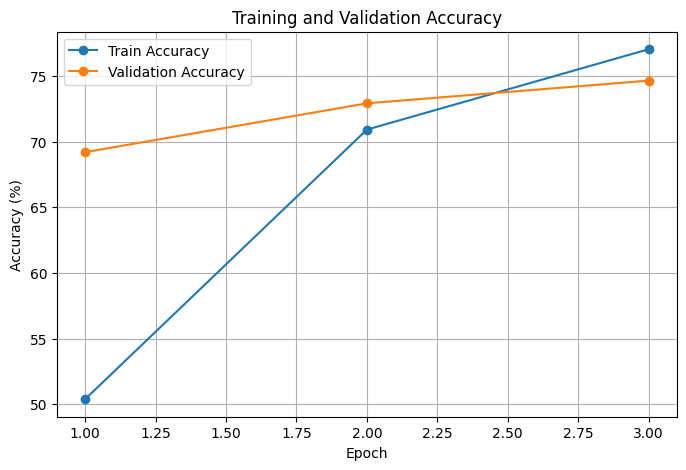

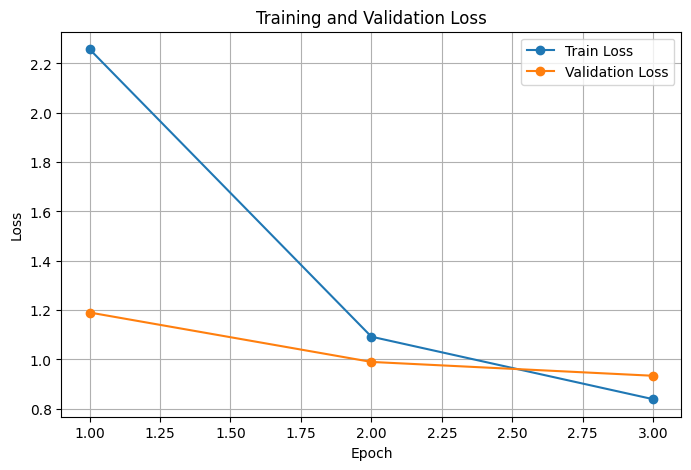

In [ ]:
import os
import random
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Subset
import torch

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Local dataset paths
ROOT = Path("/content")
CLASSIFICATION_DIR = ROOT / "miniimagenet_classification"
FINAL_TRAIN_DIR = CLASSIFICATION_DIR / "train"
FINAL_TEST_DIR = CLASSIFICATION_DIR / "test"

# Training transformations
transform_train = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Validation and test transformations
transform_test = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load dataset without transforms for splitting
base_train_data = datasets.ImageFolder(str(FINAL_TRAIN_DIR))
test_data = datasets.ImageFolder(str(FINAL_TEST_DIR), transform=transform_test)

# Split training data into train and validation
train_size = int(0.8 * len(base_train_data))
val_size = len(base_train_data) - train_size

generator = torch.Generator().manual_seed(42)
train_subset, val_subset = random_split(
    base_train_data,
    [train_size, val_size],
    generator=generator
)

# Apply different transforms to train and validation
train_dataset = datasets.ImageFolder(str(FINAL_TRAIN_DIR), transform=transform_train)
val_dataset = datasets.ImageFolder(str(FINAL_TRAIN_DIR), transform=transform_test)

train_data = Subset(train_dataset, train_subset.indices)
val_data = Subset(val_dataset, val_subset.indices)

# Create dataloaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, num_workers=0)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False, num_workers=0)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False, num_workers=0)

print("Train:", len(train_data))
print("Validation:", len(val_data))
print("Test:", len(test_data))
print("Classes:", len(base_train_data.classes))

# Load pretrained MobileNetV2
model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)

# Replace final layer with 100 output classes
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 100)

# Move model to device
model = model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

print("Model is ready")

# Lists for plotting curves
train_accs = []
val_accs = []
train_losses = []
val_losses = []

# Number of epochs
epochs = 3

# Training loop
for epoch in range(epochs):
    model.train()

    train_correct = 0
    train_total = 0
    train_loss = 0.0
    train_batches = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_batches += 1

        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total
    avg_train_loss = train_loss / train_batches

    # Validation
    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0
    val_batches = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            val_batches += 1

            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total
    avg_val_loss = val_loss / val_batches

    # Save values for plotting
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

# Final testing
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print("Test Accuracy:", test_acc)

# Plot accuracy curves
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_accs, marker="o", label="Train Accuracy")
plt.plot(range(1, epochs + 1), val_accs, marker="o", label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, marker="o", label="Train Loss")
plt.plot(range(1, epochs + 1), val_losses, marker="o", label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

## Wavelet Compression and Visual Comparison

This code applies wavelet-based compression to the Mini-ImageNet test set and creates compressed versions of the images at three different compression ratios: 2:1, 5:1, and 10:1. The goal is to simulate different levels of information removal and study how the model performance changes as the image quality decreases.

The compression process uses the Haar wavelet transform. Each RGB channel of an image is processed separately. First, the image is converted to a NumPy array, then the discrete wavelet transform is applied using `pywt.wavedec2`. The wavelet coefficients are converted into a single array, and only the largest coefficients are kept according to the selected compression ratio. Smaller coefficients are removed using hard thresholding, which sets low-magnitude values to zero. After that, the image is reconstructed using the inverse wavelet transform.

The compressed images are saved into separate folders for each ratio:
- `ratio_2_1`
- `ratio_5_1`
- `ratio_10_1`

This creates three compressed versions of the test set that can later be used to evaluate the model under different compression levels.



## Compression Method

The compression strategy is based on coefficient thresholding in the wavelet domain. For each image channel, the code keeps only a fraction of the largest wavelet coefficients and removes the rest. This approach preserves the most important image structures while discarding less significant details. Hard thresholding is used here because it is simple, effective, and easy to interpret.



## Visual Comparison

After generating the compressed datasets, the code provides an interactive visualization tool. The user can enter an image index, and the code displays the selected image in four versions:
- Original
- 2:1 compressed
- 5:1 compressed
- 10:1 compressed

This visual comparison helps show how image details are gradually lost as the compression ratio increases. The 2:1 version usually remains very close to the original, while the 10:1 version shows much stronger distortion and loss of fine details.



ratio_10_1: 100%|██████████| 100/100 [00:08<00:00, 12.06it/s]


Compression completed
['ratio_5_1', 'ratio_10_1', 'ratio_2_1']
Enter image number: 2


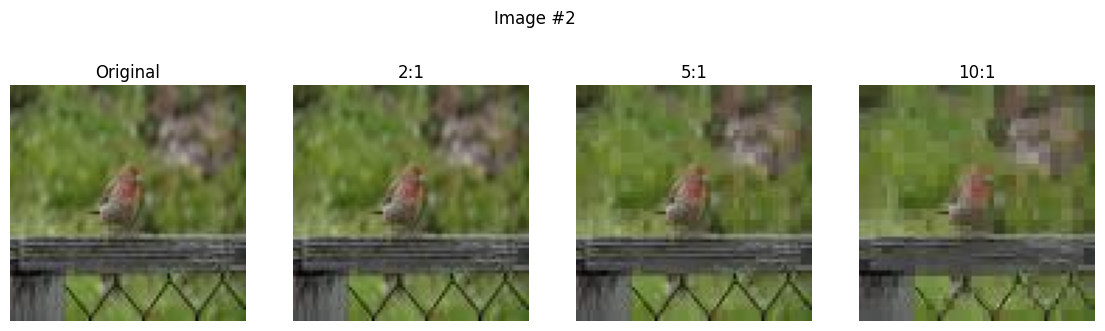

In [ ]:
# Wavelet Compression
!pip install -q PyWavelets pillow tqdm

import os
import shutil
import numpy as np
import pywt
import matplotlib.pyplot as plt

from PIL import Image
from pathlib import Path
from tqdm import tqdm

# Local dataset folders
ROOT = Path("/content")
CLASSIFICATION_DIR = ROOT / "miniimagenet_classification"
FINAL_TEST_DIR = CLASSIFICATION_DIR / "test"

# Local compressed output folder
COMPRESSED_ROOT = ROOT / "compressed_test"

# Compression ratios
ratios = {
    "ratio_2_1": 2,
    "ratio_5_1": 5,
    "ratio_10_1": 10
}

# Remove old compressed folders
shutil.rmtree(COMPRESSED_ROOT, ignore_errors=True)
COMPRESSED_ROOT.mkdir(parents=True, exist_ok=True)

# Wavelet compression function
def wavelet_compress_rgb(img, ratio, wavelet="haar"):
    img = np.array(img).astype(np.float32)
    compressed_channels = []

    # Keep fraction based on compression ratio
    keep_fraction = 1 / ratio

    # Compress each RGB channel separately
    for c in range(3):
        channel = img[:, :, c]

        # Apply wavelet transform
        coeffs = pywt.wavedec2(channel, wavelet, level=2)
        arr, slices = pywt.coeffs_to_array(coeffs)

        # Keep only largest coefficients
        flat = np.abs(arr).flatten()
        k = max(1, int(len(flat) * keep_fraction))
        threshold = np.partition(flat, -k)[-k]

        # Hard thresholding
        arr_compressed = arr * (np.abs(arr) >= threshold)

        # Reconstruct image
        coeffs_compressed = pywt.array_to_coeffs(
            arr_compressed,
            slices,
            output_format="wavedec2"
        )

        reconstructed = pywt.waverec2(coeffs_compressed, wavelet)
        reconstructed = reconstructed[:img.shape[0], :img.shape[1]]

        compressed_channels.append(reconstructed)

    # Merge RGB channels
    compressed = np.stack(compressed_channels, axis=2)
    compressed = np.clip(compressed, 0, 255).astype(np.uint8)

    return Image.fromarray(compressed)

# Generate compressed datasets
for ratio_name, ratio in ratios.items():
    out_dir = COMPRESSED_ROOT / ratio_name

    for class_dir in tqdm(list(FINAL_TEST_DIR.iterdir()), desc=ratio_name):
        if not class_dir.is_dir():
            continue

        out_class_dir = out_dir / class_dir.name
        out_class_dir.mkdir(parents=True, exist_ok=True)

        for img_path in class_dir.iterdir():
            if img_path.is_file():
                try:
                    img = Image.open(img_path).convert("RGB")
                    compressed_img = wavelet_compress_rgb(img, ratio)
                    compressed_img.save(out_class_dir / img_path.name)
                except:
                    pass

print("Compression completed")
print(os.listdir(COMPRESSED_ROOT))

# Visual comparison
original_path = FINAL_TEST_DIR
compressed_path = COMPRESSED_ROOT

# Get all classes
classes = sorted(os.listdir(original_path))

# User input
img_index = int(input("Enter image number: "))

# Collect all image paths
all_images = []

for cls in classes:
    class_dir = original_path / cls
    for img_name in os.listdir(class_dir):
        all_images.append((cls, img_name))

# Select image
selected_class, selected_image = all_images[img_index]

# Original image
orig_img = Image.open(
    original_path / selected_class / selected_image
).convert("RGB")

# Compressed images
img_2 = Image.open(
    compressed_path / "ratio_2_1" / selected_class / selected_image
).convert("RGB")

img_5 = Image.open(
    compressed_path / "ratio_5_1" / selected_class / selected_image
).convert("RGB")

img_10 = Image.open(
    compressed_path / "ratio_10_1" / selected_class / selected_image
).convert("RGB")

# Plot
plt.figure(figsize=(14, 4))

plt.subplot(1, 4, 1)
plt.imshow(orig_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(img_2)
plt.title("2:1")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(img_5)
plt.title("5:1")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(img_10)
plt.title("10:1")
plt.axis("off")

plt.suptitle(f"Image #{img_index}")
plt.show()

## Evaluation on Wavelet-Compressed Images

This code evaluates the pretrained MobileNetV2 model on the wavelet-compressed test datasets using three compression ratios: 2:1, 5:1, and 10:1. The same preprocessing steps used for the original test set are applied to the compressed images.

For each compression ratio, the classification accuracy is calculated and compared with the original baseline accuracy. Finally, a bar chart is generated to visualize how the model performance changes as the compression level increases.

Original Accuracy : 75.15
2:1 Accuracy      : 75.15
5:1 Accuracy      : 68.84
10:1 Accuracy     : 48.23


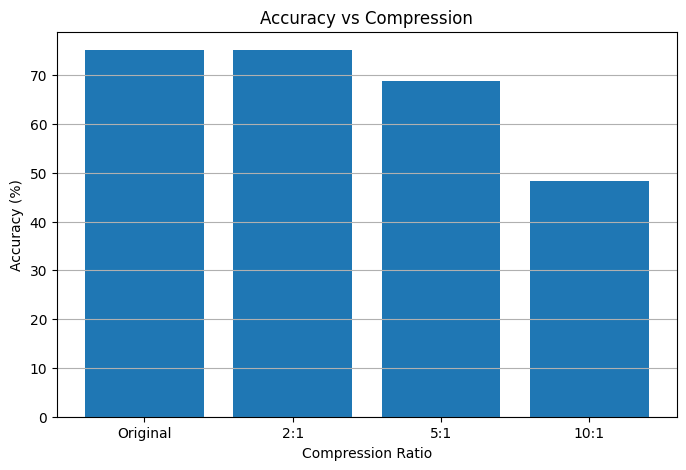

In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from pathlib import Path

# Local compressed datasets folder
ROOT = Path("/content")

COMPRESSED_ROOT = ROOT / "compressed_test"

# Function to evaluate compressed datasets
def evaluate(path):

    data = datasets.ImageFolder(
        str(path),
        transform=transform_test
    )

    loader = DataLoader(
        data,
        batch_size=64,
        shuffle=False,
        num_workers=0
    )

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    return 100 * correct / total

# Evaluate compressed datasets
acc_2 = evaluate(COMPRESSED_ROOT / "ratio_2_1")

acc_5 = evaluate(COMPRESSED_ROOT / "ratio_5_1")

acc_10 = evaluate(COMPRESSED_ROOT / "ratio_10_1")

# Print accuracies
print("Original Accuracy :", test_acc)
print("2:1 Accuracy      :", acc_2)
print("5:1 Accuracy      :", acc_5)
print("10:1 Accuracy     :", acc_10)

# Plot accuracy comparison
labels = ["Original", "2:1", "5:1", "10:1"]

values = [test_acc, acc_2, acc_5, acc_10]

plt.figure(figsize=(8,5))

plt.bar(labels, values)

plt.xlabel("Compression Ratio")
plt.ylabel("Accuracy (%)")

plt.title("Accuracy vs Compression")

plt.grid(axis="y")

plt.show()

## Class-wise Compression Analysis

This code analyzes which image classes are most affected by wavelet compression. The original test set and the highly compressed 10:1 test set are evaluated separately using the pretrained MobileNetV2 model.

For each class, the classification accuracy is computed before and after compression. The difference between the original accuracy and the compressed accuracy is calculated as the accuracy drop. The classes are then sorted according to the largest drop in performance.

The top 10 most affected classes are displayed and visualized using a bar chart. In addition, sample images from the most affected classes are shown to help visually analyze why these classes are more sensitive to aggressive compression.

This analysis helps identify which types of visual features are more vulnerable to information loss caused by wavelet coefficient thresholding. Classes containing fine textures, detailed patterns, or subtle object features tend to experience larger performance degradation under strong compression.

Most affected classes:

Class 41 | Original: 85.00% | Compressed: 14.00% | Drop: 71.00%
Class 98 | Original: 89.00% | Compressed: 31.00% | Drop: 58.00%
Class 76 | Original: 83.00% | Compressed: 28.00% | Drop: 55.00%
Class 2 | Original: 73.00% | Compressed: 22.00% | Drop: 51.00%
Class 9 | Original: 77.00% | Compressed: 26.00% | Drop: 51.00%
Class 61 | Original: 83.00% | Compressed: 36.00% | Drop: 47.00%
Class 19 | Original: 65.00% | Compressed: 19.00% | Drop: 46.00%
Class 27 | Original: 87.00% | Compressed: 41.00% | Drop: 46.00%
Class 32 | Original: 77.00% | Compressed: 32.00% | Drop: 45.00%
Class 52 | Original: 72.00% | Compressed: 27.00% | Drop: 45.00%


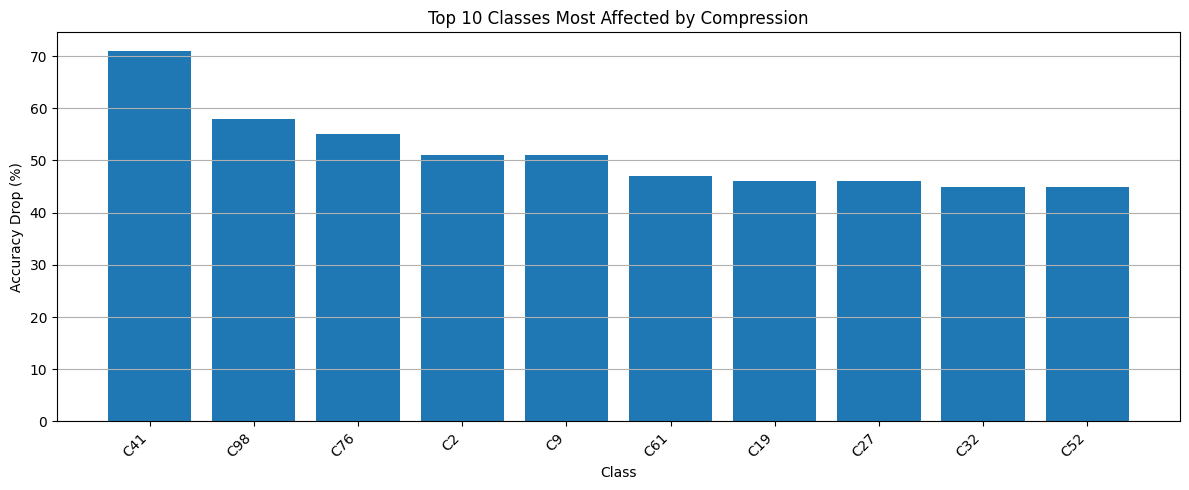

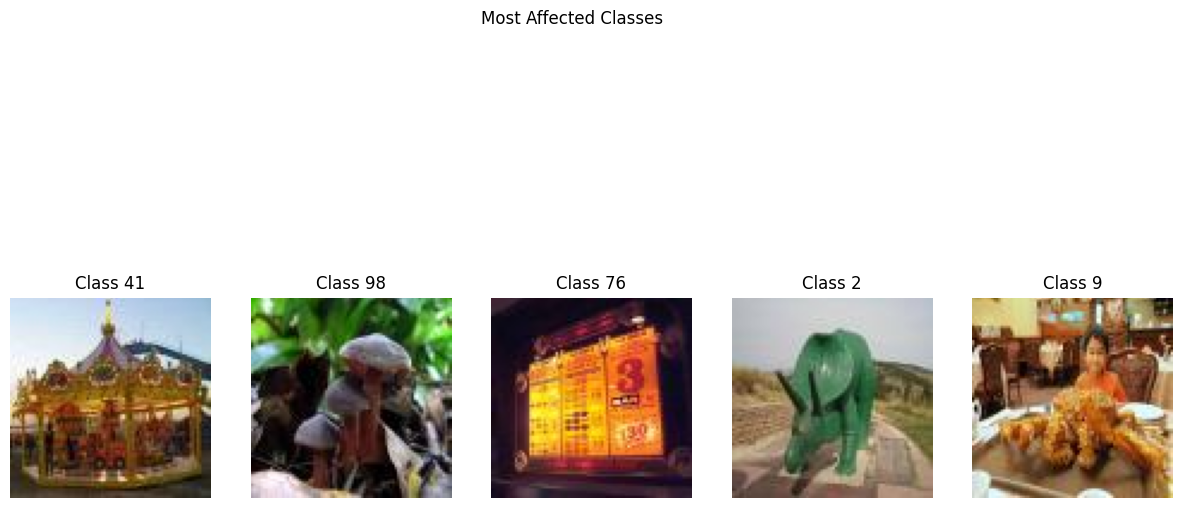

In [ ]:
# Analyze Which Image Classes Are Most Affected by Compression

from collections import defaultdict
from torchvision import datasets
from torch.utils.data import DataLoader
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

# Local dataset folders
ROOT = Path("/content")
CLASSIFICATION_DIR = ROOT / "miniimagenet_classification"
FINAL_TEST_DIR = CLASSIFICATION_DIR / "test"
COMPRESSED_ROOT = ROOT / "compressed_test"

# Compute accuracy for each class
def per_class_accuracy(loader, model, num_classes):
    class_correct = defaultdict(int)
    class_total = defaultdict(int)

    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = outputs.max(1)

            for label, pred in zip(labels, predicted):
                label = label.item()
                class_total[label] += 1
                if label == pred.item():
                    class_correct[label] += 1

    acc = {}
    for cls in range(num_classes):
        if class_total[cls] > 0:
            acc[cls] = 100 * class_correct[cls] / class_total[cls]
        else:
            acc[cls] = 0.0

    return acc

# Load original test set
original_test_data = datasets.ImageFolder(
    str(FINAL_TEST_DIR),
    transform=transform_test
)

original_test_loader = DataLoader(
    original_test_data,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

# Load compressed test set (10:1)
compressed_test_data = datasets.ImageFolder(
    str(COMPRESSED_ROOT / "ratio_10_1"),
    transform=transform_test
)

compressed_test_loader = DataLoader(
    compressed_test_data,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

num_classes = len(original_test_data.classes)

# Per-class accuracy
orig_acc = per_class_accuracy(original_test_loader, model, num_classes)
comp_acc = per_class_accuracy(compressed_test_loader, model, num_classes)

# Compute accuracy drop for each class
drops = []
for cls_idx in range(num_classes):
    drop = orig_acc[cls_idx] - comp_acc[cls_idx]
    drops.append((cls_idx, orig_acc[cls_idx], comp_acc[cls_idx], drop))

# Sort by largest drop
drops_sorted = sorted(drops, key=lambda x: x[3], reverse=True)

# Print top 10 most affected classes
print("Most affected classes:\n")
for cls_idx, oacc, cacc, drop in drops_sorted[:10]:
    print(
        f"Class {cls_idx} | "
        f"Original: {oacc:.2f}% | "
        f"Compressed: {cacc:.2f}% | "
        f"Drop: {drop:.2f}%"
    )

# Plot top 10 affected classes
top = drops_sorted[:10]
labels = [f"C{x[0]}" for x in top]
drop_values = [x[3] for x in top]

plt.figure(figsize=(12, 5))
plt.bar(labels, drop_values)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Class")
plt.ylabel("Accuracy Drop (%)")
plt.title("Top 10 Classes Most Affected by Compression")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

# Show sample images from the most affected classes
top_classes = [x[0] for x in drops_sorted[:5]]

plt.figure(figsize=(15, 8))

for i, cls_idx in enumerate(top_classes):
    class_name = original_test_data.classes[cls_idx]
    class_dir = FINAL_TEST_DIR / class_name
    sample_img = list(class_dir.glob("*"))[0]
    img = Image.open(sample_img).convert("RGB")

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Class {cls_idx}")
    plt.axis("off")

plt.suptitle("Most Affected Classes")
plt.show()